# Image context inspection

Inspect theme `image_context.json` artifacts (nearby PDF text + VLM description).
No OCR and no embeddings here.

## 1. Setup

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doc_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

image_context = importlib.reload(importlib.import_module("doc_rag.8_image_context"))
image_embeddings = importlib.reload(
    importlib.import_module("doc_rag.10_image_embeddings")
)

print("Artifact root:", image_context.DEFAULT_ARTIFACT_ROOT)
print("Context schema version:", image_context.CONTEXT_SCHEMA_VERSION)

Artifact root: C:\Users\User\Desktop\inmind\gatherly_rag\data\rag\processed_documents
Context schema version: 3


## 2. Load image contexts

In [2]:
records = image_context.load_image_context_records()
images_df = pd.DataFrame(records)

images_df["page_label"] = images_df["page_numbers"].apply(
    lambda pages: ", ".join(map(str, pages or []))
)
images_df["nearby_chars"] = images_df["nearby_text"].fillna("").str.len()
images_df["has_vlm"] = (
    images_df["visual_description"].fillna("").astype(str).str.strip().ne("")
)
images_df["retrieval_text"] = images_df.apply(
    lambda row: image_embeddings.build_image_context_text(
        row.to_dict(), include_ocr=False
    ),
    axis=1,
)

print("Documents:", images_df["file_name"].nunique())
print("Images:", len(images_df))
print("Split across pages:", int(images_df["is_split_across_pages"].sum()))
print("Empty nearby_text:", int(images_df["nearby_text"].fillna("").str.strip().eq("").sum()))
print("Missing VLM description:", int((~images_df["has_vlm"]).sum()))

display(
    images_df.groupby("file_name")
    .agg(
        images=("image_id", "size"),
        split=("is_split_across_pages", "sum"),
        with_vlm=("has_vlm", "sum"),
        median_nearby_chars=("nearby_chars", "median"),
    )
    .reset_index()
)

Documents: 16
Images: 480
Split across pages: 153
Empty nearby_text: 0
Missing VLM description: 0


,file_name,images,split,with_vlm,median_nearby_chars
0,Boho_Wedding.pdf,47,21,47,225.0
1,Celestial_Wedding.pdf,30,11,30,201.0
2,Classic_Wedding.pdf,15,7,15,241.0
3,Enchanted_Forest_Wedding.pdf,10,7,10,257.0
4,Garden_Wedding.pdf,52,17,52,248.5
5,Modern_Wedding.pdf,51,7,51,193.0
6,Moody_Wedding.pdf,34,12,34,227.0
7,Romantic_Wedding.pdf,41,10,41,214.0
8,Rustic_Wedding.pdf,54,17,54,154.0
9,Tropical_Wedding.pdf,21,8,21,214.0


## 3. Select images to inspect

In [3]:
SELECTED_DOCUMENT = "Boho_Wedding.pdf" 
SELECTED_PAGES = None 
SEARCH_TEXT = "invitation"
SPLIT_IMAGES_ONLY = False
MAX_IMAGES = 8
IMAGE_DISPLAY_WIDTH = 340

In [4]:
selected = images_df.copy()
if SELECTED_DOCUMENT:
    selected = selected[selected["file_name"] == SELECTED_DOCUMENT]
if SELECTED_PAGES:
    wanted = set(SELECTED_PAGES)
    selected = selected[
        selected["page_numbers"].apply(
            lambda pages: bool(wanted.intersection(pages or []))
        )
    ]
if SEARCH_TEXT:
    selected = selected[
        selected["nearby_text"].str.contains(
            SEARCH_TEXT, case=False, na=False, regex=False
        )
        | selected["visual_description"].str.contains(
            SEARCH_TEXT, case=False, na=False, regex=False
        )
    ]
if SPLIT_IMAGES_ONLY:
    selected = selected[selected["is_split_across_pages"]]

selected = selected.head(MAX_IMAGES).reset_index(drop=True)
print("Selected:", len(selected))
display(
    selected[
        [
            "image_id",
            "file_name",
            "page_label",
            "section_title",
            "is_split_across_pages",
            "nearby_chars",
            "has_vlm",
        ]
    ]
)

Selected: 2


,image_id,file_name,page_label,section_title,is_split_across_pages,nearby_chars,has_vlm
0,Boho_Wedding-acdffa2a1a27008e,Boho_Wedding.pdf,"1, 2",1. Send Out Your Boho Wedding Invitation,True,219,True
1,Boho_Wedding-b80c60bf9a3af0ac,Boho_Wedding.pdf,"3, 4",2. Select Your Boho Wedding Venue,True,272,True


## 4. Display image + contexts

### `Boho_Wedding-acdffa2a1a27008e`  
**Document:** Boho_Wedding.pdf  
**Pages:** 1, 2  
**Section:** 1. Send Out Your Boho Wedding Invitation  
**Split:** True

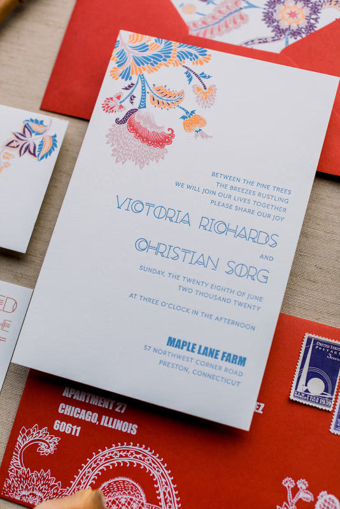

**Nearby PDF text**

1. Send Out Your Boho Wedding Invitation

Let Your Flower Child Spirit Set the Tone

Preston, CN We adore how these bohemian-inspired invitations set a unique, color-drenched, floral vibe long before the wedding itself.


**VLM visual description**

The image shows a wedding invitation with a vibrant and colorful design. The invitation is white with blue and orange floral patterns at the top. The text is in blue, listing the names of the couple, Victoria Richards and Christian Sorg, and the date and time of their wedding. The location is Maple Lane Farm in Preston, Connecticut. The envelope beneath the invitation is red with white floral designs and contains an address in Chicago, Illinois. A blue postage stamp is visible on the envelope. The overall style is festive and artistic, with a mix of bright colors and intricate patterns.


**Retrieval text** (`build_image_context_text`, OCR off)

Document: Boho Wedding
Topic: 1. Send Out Your Boho Wedding Invitation > Let Your Flower Child Spirit Set the Tone
Description: Preston, CN We adore how these bohemian-inspired invitations set a unique, color-drenched, floral vibe long before the wedding itself.
Visual description: The image shows a wedding invitation with a vibrant and colorful design. The invitation is white with blue and orange floral patterns at the top. The text is in blue, listing the names of the couple, Victoria Richards and Christian Sorg, and the date and time of their wedding. The location is Maple Lane Farm in Preston, Connecticut. The envelope beneath the invitation is red with white floral designs and contains an address in Chicago, Illinois. A blue postage stamp is visible on the envelope. The overall style is festive and artistic, with a mix of bright colors and intricate patterns.






### `Boho_Wedding-b80c60bf9a3af0ac`  
**Document:** Boho_Wedding.pdf  
**Pages:** 3, 4  
**Section:** 2. Select Your Boho Wedding Venue  
**Split:** True

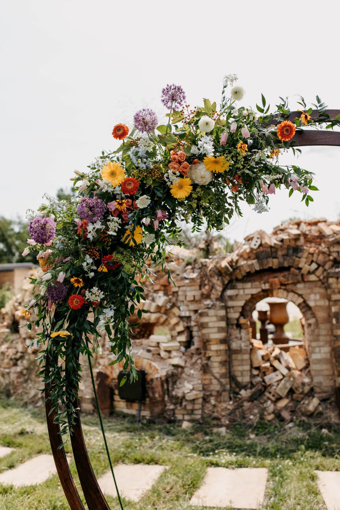

**Nearby PDF text**

2. Select Your Boho Wedding Venue

Look For Unique Features

Tonica, IL Everything about this bohemian wedding wows, from the unique invitations to the Watson Events | venue: Topnotch Resort thoughtful guest favors, but we especially love the ceremony setting with a round


**VLM visual description**

The image features a vibrant floral archway set against the backdrop of a partially ruined brick structure. The arch is adorned with a lush arrangement of colorful flowers, including sunflowers, daisies, and various other blooms in shades of yellow, orange, purple, and white. The greenery is abundant, with leaves and branches adding texture and depth to the display. The setting appears to be outdoors, possibly in a garden or park, with a grassy area and a pathway leading up to the arch. The rustic brick ruins in the background suggest an old, possibly historical, location. The overall visual style is natural and rustic, with a focus on the beauty of the flowers and the contrast between the vibrant colors and the muted tones of the ruins.


**Retrieval text** (`build_image_context_text`, OCR off)

Document: Boho Wedding
Topic: 2. Select Your Boho Wedding Venue > Look For Unique Features
Description: Tonica, IL Everything about this bohemian wedding wows, from the unique invitations to the Watson Events | venue: Topnotch Resort thoughtful guest favors, but we especially love the ceremony setting with a round
Visual description: The image features a vibrant floral archway set against the backdrop of a partially ruined brick structure. The arch is adorned with a lush arrangement of colorful flowers, including sunflowers, daisies, and various other blooms in shades of yellow, orange, purple, and white. The greenery is abundant, with leaves and branches adding texture and depth to the display. The setting appears to be outdoors, possibly in a garden or park, with a grassy area and a pathway leading up to the arch. The rustic brick ruins in the background suggest an old, possibly historical, location. The overall visual style is natural and rustic, with a focus on the beauty of the fl

In [5]:
def show_image_context(row, width=340):
    display(Markdown(
        f"### `{row['image_id']}`  \n"
        f"**Document:** {row['file_name']}  \n"
        f"**Pages:** {row['page_label']}  \n"
        f"**Section:** {row.get('section_title', '')}  \n"
        f"**Split:** {row['is_split_across_pages']}"
    ))

    image_path = Path(row["image_path"])
    if image_path.is_file():
        with Image.open(image_path) as image:
            height = max(1, round(image.height * width / image.width))
            display(image.copy().resize((width, height)))
    else:
        display(Markdown(f"**Missing image:** `{image_path}`"))

    display(Markdown("**Nearby PDF text**"))
    print(row.get("nearby_text") or "(empty)")

    display(Markdown("**VLM visual description**"))
    print(str(row.get("visual_description") or "").strip() or "(empty)")

    display(Markdown("**Retrieval text** (`build_image_context_text`, OCR off)"))
    print(row["retrieval_text"])
    print("\n\n\n")


for _, row in selected.iterrows():
    show_image_context(row, IMAGE_DISPLAY_WIDTH)

## 5. Readiness check

In [6]:
empty_nearby = int(images_df["nearby_text"].fillna("").str.strip().eq("").sum())
missing_vlm = int((~images_df["has_vlm"]).sum())

print("Images:", len(images_df))
print("Empty nearby_text:", empty_nearby)
print("Missing VLM description:", missing_vlm)

if missing_vlm:
    print("Not ready: regenerate VLM descriptions for missing images.")
elif empty_nearby > len(images_df) * 0.2:
    print("Warning: many empty nearby_text fields; inspect filters above.")


Images: 480
Empty nearby_text: 0
Missing VLM description: 0
